### CH 5.1 텍스트 생성 모델 평가하기

In [3]:
import torch
from previous_chapters import GPTModel

GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 256,
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.1,
    "qkv_bias": False
}

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval()

GPTModel(
  (tok_emb): Embedding(50257, 768)
  (pos_emb): Embedding(256, 768)
  (drop_emb): Dropout(p=0.1, inplace=False)
  (trf_blocks): Sequential(
    (0): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features=768, out_features=768, bias=False)
        (W_key): Linear(in_features=768, out_features=768, bias=False)
        (W_value): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (drop_shortcut): Dropout(p=0.1, inplace=False)
    )
    (1): TransformerBlock(
      (att): MultiHeadAttention(
        (W_query): Linear(in_features

In [4]:
import tiktoken
from previous_chapters import generate_text_simple

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0)  # .unsqueeze(0) adds a batch dimension
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0) # 배치 차원을 제거합니다. (예: [1, 10] -> [10])
    return tokenizer.decode(flat.tolist())

start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"]
)
print("출력 텍스트:\n", token_ids_to_text(token_ids, tokenizer))

출력 텍스트:
 Every effort moves you rentingetic wasnم refres RexMeCHicular stren


In [5]:
inputs = torch.tensor([[16833, 3626, 6100],
                       [40, 1107, 588]])
targets = torch.tensor([[3626, 6100, 345],
                        [1107, 588, 11311]])

In [6]:
with torch.no_grad():
    logits = model(inputs)
probas = torch.softmax(logits, dim=-1)
print(probas.shape)

torch.Size([2, 3, 50257])


In [7]:
token_ids = torch.argmax(probas, dim=-1, keepdim=True)
print("토큰 ID:\n", token_ids)

토큰 ID:
 tensor([[[16657],
         [  339],
         [42826]],

        [[49906],
         [29669],
         [41751]]])


In [8]:
print(f"첫 번째 샘플의 타겟: {token_ids_to_text(targets[0], tokenizer)}")
print(f"두 번째 샘플의 타겟: {token_ids_to_text(token_ids[0].flatten(), tokenizer)}")

첫 번째 샘플의 타겟:  effort moves you
두 번째 샘플의 타겟:  Armed heNetflix


In [9]:
text_ids = 0
target_probas_1 = probas[text_ids, [0, 1, 2], targets[text_ids]]
print("텍스트 1:", target_probas_1)

text_ids = 1
target_probas_2 = probas[text_ids, [0, 1, 2], targets[text_ids]]
print("텍스트 2:", target_probas_2)

텍스트 1: tensor([7.4540e-05, 3.1061e-05, 1.1563e-05])
텍스트 2: tensor([1.0337e-05, 5.6776e-05, 4.7559e-06])


#### 역전파  
타겟 토큰에 해당하는 softmax 확률값을 어떻게 최대화할까? 크게 보면 생성하고자 하는 토큰 ID에 대해 모델이 높은 값을  
출력하도록 가중치를 업데이트함. 이 가중치 업데이트는 심층 신경망을 훈련하는 표준 기법인 역전파라는 과정을 통해 수행된다.  
역전파에는 모델의 예측과 실제 출력 사이의 차이를 계산하는 손실 함수가 필요함. 이 손실 함수는 모델의 예측이 타겟 값과  
얼마나 멀리 떨어져 있는지를 측정함.

In [10]:
log_probas = torch.log(torch.cat((target_probas_1, target_probas_2)))
print("로그 확률:\n", log_probas)

로그 확률:
 tensor([ -9.5042, -10.3796, -11.3677, -11.4798,  -9.7764, -12.2561])


In [11]:
avg_log_probas = torch.mean(log_probas)
print("평균 로그 확률:", avg_log_probas)

평균 로그 확률: tensor(-10.7940)


In [12]:
neg_avg_log_probas = -avg_log_probas
print("음수 평균 로그 확률:", neg_avg_log_probas)

음수 평균 로그 확률: tensor(10.7940)


#### Cross-Entropy loss  
CELoss는 ML와 DL에서 인기있게 사용되는 측정 지표로써 두 확률 분포 사이의 차이를 계산한다. 일반적으로 레이블의 정답 분포와 모델의 예측 분포 사이를 측정함.  


In [13]:
print("로짓 크기: ", logits.shape)
print("타겟 크기: ", targets.shape)

로짓 크기:  torch.Size([2, 3, 50257])
타겟 크기:  torch.Size([2, 3])


In [14]:
logits_flat = logits.flatten(0, 1) # 배치 차원과 시퀀스 차원을 합칩니다.
targets_flat = targets.flatten()
print("로짓 플랫 크기: ", logits_flat.shape)
print("펼친 타겟 크기: ", targets_flat.shape)

로짓 플랫 크기:  torch.Size([6, 50257])
펼친 타겟 크기:  torch.Size([6])


In [15]:
loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
print("손실:", loss)

손실: tensor(10.7940)


#### 혼잡도(Perplexity)  
혼잡도라는 뜻의 Perplexity는 크로스 엔트로피 손실과 함께 언어 모델링 같은 작업에서 모델의 성능을 평가하기 위해 많이 사용하는 측정 지표 중 하나이다.  
시퀀스의 다음 토큰을 예측하는 데 모델의 불확실성을 이행할 수 있는 방법임.  
혼잡도는 모델이 예측이 실제 분포에 더 가깝다는 것을 나타낸다. 혼잡도는 perplexity = torch.exp(loss)와 같이 계산한다. 앞서 계산된 손실에 적용하면  
tensor(48725.8203)을 얻는다.  
혼잡돈느 모델이 각 단계에서 불확실한 실제 어휘사전 크기를 나타내기 때문에 원시 손실 값보다 이해하기 더 쉽다. 이 예에서는 다음 토큰을 생성하는 데  
어휘사전에 있는 48,725개의 토큰 중에서 어떤 것을 선택할지 불확실하다는 의미임.

In [16]:
file_path = "the-verdict.txt"
with open(file_path, "r", encoding="utf-8") as f:
    text_data = f.read()
    
total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))
print("문자 수:", total_characters)
print("토큰 수:", total_tokens)

문자 수: 20479
토큰 수: 5145


In [17]:
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]

In [18]:
from previous_chapters import create_dataloader_v1
torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

In [19]:
print("훈련 데이터 로더:")
for x, y in train_loader:
    print(x.shape, y.shape)
    
print("\n검증 데이터 로더:")
for x, y in val_loader:
    print(x.shape, y.shape)

훈련 데이터 로더:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

검증 데이터 로더:
torch.Size([2, 256]) torch.Size([2, 256])


In [20]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(
        logits.flatten(0, 1), target_batch.flatten()
    )
    return loss

In [21]:
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.0
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
        
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(
                input_batch, target_batch, model, device
            )
            total_loss += loss.item() # 각 배치에 대한 손실을 합산합니다.
        else:
            break
    return total_loss / num_batches # 평균 손실을 반환합니다.

calc_loss_loader 함수는 주어진 데이터 로더에 있는 모든 배치를 순회하면서 total_loss에 손실을 누적한다.  
그런 다음 총 배치 개수에 대해 손실의 평균을 계산한다. 아니면 num_batches 매개변수에 적은 배치 횟수를 지정하여 훈련 속도를 높일 수 있다.  

In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device) # CUDA가 사용 가능한 경우 모델을 GPU로 이동합니다.
with torch.no_grad(): # 훈련하는 상황이 아니므로, 기울기 계산을 비활성화합니다.
    train_loss = calc_loss_loader(train_loader, model, device) # device 매개변수를 사용해서 LLM 모델과 데이터를 동일한 장치로 데이터 이동
    val_loss = calc_loss_loader(val_loader, model, device)
    
print("훈련 손실:", train_loss)
print("검증 손실:", val_loss)

훈련 손실: 10.98758347829183
검증 손실: 10.98110580444336


### 5.2 LLM 훈련하기

In [32]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs, eval_freq, eval_iter, start_context, tokenizer):
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1
    
    for epoch in range(num_epochs):
        model.train() # 모델을 훈련 모드로 설정합니다.
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() # 이전 배치의 반복에서 얻은 기울기를 초기화합니다.
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward() # 손실에 대한 기울기를 계산합니다.
            optimizer.step() # 모델의 매개변수를 업데이트합니다.
            tokens_seen += input_batch.numel() # 현재 배치의 토큰 수를 누적합니다.
            global_step += 1
            
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"에포크 {epoch+1} (step {global_step:06d})"
                      f"훈련 손실 {train_loss:.3f}"
                      f"검증 손실 {val_loss:.3f}"
                      )
                
            generate_and_print_text(model, tokenizer, device, start_context)
    return train_losses, val_losses, track_tokens_seen         

In [24]:
def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval() # 모델을 평가 모드로 설정합니다.
    with torch.no_grad(): # 평가 중에는 기울기 계산을 비활성화합니다.
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train() # 평가가 끝난 후에는 모델을 다시 훈련 모드로 설정합니다.
    return train_loss, val_loss

In [31]:
def generate_and_print_text(model, tokenizer, device, start_context):
    model.eval() # 모델을 평가 모드로 설정합니다.
    context_size = model.pos_emb.weight.shape[0] # 모델의 위치 임베딩 크기를 가져옵니다.
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad(): # 평가 중에는 기울기 계산을 비활성화합니다.
        token_ids = generate_text_simple(
            model=model, idx=encoded, max_new_tokens=50, context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))
    model.train() # 평가가 끝난 후에는 모델을 다시 훈련 모드로 설정합니다.

In [33]:
torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.0004, weight_decay=0.1
)
num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device, num_epochs=num_epochs, 
    eval_freq=5, start_context="Every effort moves you", tokenizer=tokenizer, eval_iter=5
)

에포크 1 (step 000000)훈련 손실 9.820검증 손실 9.927
Every effort moves you,,,,,,,,,,,,,,,,,,,,,,,,, the the the of the the,,,,,,,,,,,,,,,,,,,
Every effort moves you,.                                                
Every effort moves you,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Every effort moves you,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Every effort moves you,,,,,,, the the,,,,, the,,,, the,,,,, the the,, the,, the the,,,,,,, the the the the,,,,,
에포크 1 (step 000005)훈련 손실 8.066검증 손실 8.338
Every effort moves you, the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the the
Every effort moves you, the, the the the the the the the the the the the the the the the the the the the the the                          
Every effort moves you,,,,,,,,,,,,.                                     
Every effort moves you,,,,,,,,,,,,.                            

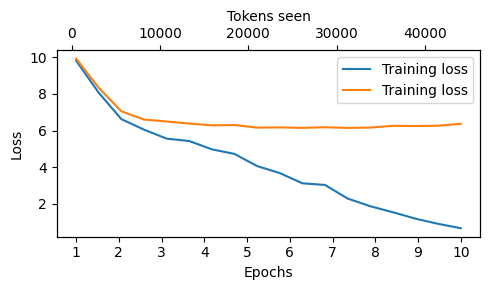

In [34]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(
        epochs_seen, val_losses, label="Training loss"
    )
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax2 = ax1.twiny()
    ax2.plot(tokens_seen, train_losses, alpha=0)
    ax2.set_xlabel("Tokens seen")
    fig.tight_layout()
    plt.show()
    
epochs_tensor = torch.linspace(1, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)